# Civic Trust 2026 — screening, quotas, weighting

**The study.** A national attitude survey on trust in institutions, fielded through an online panel: informed consent, screen-outs for minors and people living abroad, panel redirects, quotas by region and gender, weighting to census margins, and labelled tables, a banner, a report and SPSS/R files at the end.

**What this notebook shows.** A codebook with structured missing values → the questionnaire with `ContentPage` / `DisqualificationPage` / `FinalPage`, typed `next_if` routing, a randomized `Matrix` block and both `MultiChoice` layouts → strict validation and lint → simulation with the right missingness pattern → a **real local deployment** with HTTP submissions and what the browser runtime stores → quota monitoring → cleaning, raking weights, `data.report` / `data.analysis` / `data.tables`, charts, a `Report`, and every export format.

Every cell below was executed against siamang 0.6.0; outputs are saved inline.

> Charts need `pip install "siamang[charts]"`. Run the cells in order — the local server started in section 4 is stopped in section 7.

In [1]:
import dataclasses
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

import siamang as sg
from siamang.core import (
    AND, OR, ContentPage, DisqualificationPage, FinalPage, Matrix, MissingValue,
    MultiChoice, Quota, validate_options,
)
from siamang.core.question import question_output_name

print("siamang", sg.__version__, "| pandas", pd.__version__)
from siamang.reporting.tables import CrossTable, FreqTable, GroupMeanTable
for _cls in (FreqTable, CrossTable, GroupMeanTable):   # text/plain fallback = Markdown table; the HTML view is unchanged
    get_ipython().display_formatter.formatters["text/plain"].for_type(_cls, lambda t, p, cycle: p.text(t.to_markdown()))
OUT = Path("out"); OUT.mkdir(exist_ok=True)

siamang 0.6.0 | pandas 3.0.5


## 1. The codebook

Every `Variable` is defined once and registered in one `VariableMap`. The map is passed to the `Questionnaire`, travels with simulated and collected data, and becomes the SPSS/Stata labels on export.

A declared missing code must also appear in `labels` (here `98: "Don't know"`), otherwise lint reports `MISSING_CODE_NOT_IN_LABELS`. Because the Matrix derives its columns from the shared labels, "Don't know" becomes a regular column whose code is declared missing.

In [2]:
TRUST5 = {1: "No trust at all", 2: "Little trust", 3: "Some trust",
          4: "Quite a lot of trust", 5: "Complete trust"}
YESNO = {0: "No", 1: "Yes"}

# ── Screening ────────────────────────────────────────────────────────────────
consent = sg.Variable("consent", scale="nominal", label="Informed consent",
                      labels={1: "I agree to take part", 2: "I do not agree"})
age = sg.Variable("age", scale="ratio", label="Age (years)", dtype="int", valid_range=(16, 99))
region = sg.Variable(
    "region", scale="nominal", label="Region of residence",
    labels={1: "Capital", 2: "North", 3: "South", 4: "East", 99: "Outside the country"},
)

# ── Demographics ─────────────────────────────────────────────────────────────
gender = sg.Variable(
    "gender", scale="nominal", label="Gender",
    labels={1: "Woman", 2: "Man", 3: "Other", 99: "Prefer not to say"},
    missing=(MissingValue(99, "Prefer not to say", kind="refusal"),),
)
education = sg.Variable(
    "education", scale="ordinal", label="Highest education",
    labels={1: "Primary", 2: "Secondary", 3: "Vocational", 4: "University"},
)
employment = sg.Variable(
    "employment", scale="nominal", label="Employment status",
    labels={1: "Employed full-time", 2: "Employed part-time", 3: "Self-employed",
            4: "Student", 5: "Not working"},
)
work_sector = sg.Variable("work_sector", scale="nominal", label="Sector of employment",
                          labels={1: "Public", 2: "Private", 3: "Non-profit"})
work_hours = sg.Variable("work_hours", scale="ratio", label="Weekly working hours",
                         dtype="int", valid_range=(0, 80))

# ── Trust battery (five ordinal items, one construct) ────────────────────────
def _trust(name: str, label: str) -> sg.Variable:
    return sg.Variable(
        name, scale="ordinal", label=label,
        labels={**TRUST5, 98: "Don't know"},
        missing=(MissingValue(98, "Don't know", kind="dont_know"),),
        construct="institutional_trust", source="ESS Round 10 (adapted)",
    )

trust_govt = _trust("trust_govt", "Trust in the national government")
trust_parliament = _trust("trust_parliament", "Trust in parliament")
trust_courts = _trust("trust_courts", "Trust in the courts")
trust_police = _trust("trust_police", "Trust in the police")
trust_media = _trust("trust_media", "Trust in the news media")
TRUST_ITEMS = [trust_govt, trust_parliament, trust_courts, trust_police, trust_media]

interest = sg.Variable("interest", scale="ordinal", label="Interest in politics",
                       labels={1: "Not at all", 2: "A little", 3: "Somewhat", 4: "Quite", 5: "Very"})

# ── Media use: array-mode MultiChoice (one column holding a list of codes) ────
news_sources = sg.Variable(
    "news_sources", scale="nominal", label="Main news sources",
    labels={1: "Television", 2: "Newspapers", 3: "News websites", 4: "Social media",
            5: "Radio", 99: "I do not follow the news"},
)

# ── Civic activity: wide-mode MultiChoice (one 0/1 column per activity) ──────
act_vote = sg.Variable("act_vote", scale="nominal", label="Voted in an election", labels=YESNO)
act_petition = sg.Variable("act_petition", scale="nominal", label="Signed a petition", labels=YESNO)
act_protest = sg.Variable("act_protest", scale="nominal", label="Joined a demonstration", labels=YESNO)
act_volunteer = sg.Variable("act_volunteer", scale="nominal", label="Volunteered", labels=YESNO)
ACTIVITIES = [act_vote, act_petition, act_protest, act_volunteer]

comment = sg.Variable("comment", scale="nominal", label="Open comment")
recontact = sg.Variable("recontact", scale="nominal", label="Willing to be recontacted",
                        labels={1: "Yes", 2: "No"})

variables = sg.VariableMap()
variables.add_many([
    consent, age, region, gender, education, employment, work_sector, work_hours,
    *TRUST_ITEMS, interest, news_sources, *ACTIVITIES, comment, recontact,
])
print(len(variables), "variables registered")

21 variables registered


## 2. The questionnaire and the quota plan

- **Terminal pages are gated, and the same gate hides the main pages.** `eligible` is used as `show_if` on every substantive page *and* negated on the screen-out page — `simulate()` honours page gates but does not execute routing.
- **Page-level `show_if` must be SurveyJS-exportable.** `validate()` rejects `isin()` / `notin()` in a *page* gate (fine on blocks, questions, options and in `next_if`) — hence `working = OR(...)`.
- **`next_if` takes typed expressions** — `(Expression, page_name)` pairs, validated and compiled.
- **Quotas live in `options["quota"]`** (singular). `validate_options()` checks every cell against the codebook; `survey.deploy(**options)` attaches the plan.

In [3]:
PANEL = "https://panel.example.com/return"

eligible = AND(consent.eq(1), age.ge(18), region.ne(99))
working = OR(employment.eq(1), employment.eq(2), employment.eq(3))

survey = sg.Questionnaire(
    title="Civic Trust 2026",
    variables=variables,
    pages=[
        ContentPage(
            "intro", title="About this study",
            body=("<p>This 8-minute survey asks how much people trust public institutions. "
                  "Answers are anonymous and reported only in aggregate.</p>"),
        ),
        sg.Page("consent_page", title="Your consent", items=[
            sg.SingleChoice("Do you agree to take part?", var=consent, required=True, display="buttons"),
        ]),
        DisqualificationPage(
            "no_consent", title="Thank you", show_if=consent.eq(2),
            body="<p>No problem — thanks for considering it.</p>",
            redirect_url=f"{PANEL}?status=screenout", redirect_delay=5,
        ),
        sg.Page("screener", title="A few questions first", items=[
            sg.NumericInput("How old are you?", var=age, required=True, unit="years"),
            sg.SingleChoice("Where do you currently live?", var=region, required=True, display="dropdown"),
        ]),
        DisqualificationPage(
            "screen_out", title="Thank you for your interest", show_if=~eligible,
            body="<p>This study is for adults living in the country.</p>",
            redirect_url=f"{PANEL}?status=screenout", redirect_delay=5,
        ),
        sg.Page("demographics", title="About you", show_if=eligible, items=[
            sg.SingleChoice("Which best describes you?", var=gender),
            sg.SingleChoice("What is your highest level of education?", var=education, required=True),
            sg.SingleChoice("What is your current employment status?", var=employment, required=True),
        ], next_if=[(employment.isin([4, 5]), "attitudes")]),        # skip the work page
        sg.Page("work", title="Your work", show_if=AND(eligible, working), items=[
            sg.SingleChoice("In which sector do you work?", var=work_sector),
            sg.NumericInput("How many hours do you usually work per week?", var=work_hours, unit="hours"),
        ]),
        sg.Page("attitudes", title="Trust in institutions", show_if=eligible, items=[
            sg.Block(title="Institutions", randomize=True, items=[
                sg.Matrix(
                    "How much do you trust each of the following?", var=TRUST_ITEMS,
                    subquestions=["The national government", "Parliament", "The courts",
                                  "The police", "The news media"],
                ),
                sg.LikertScale("How interested are you in politics?", var=interest,
                               points=5, left_label="Not at all", right_label="Very"),
            ]),
            sg.MultiChoice("Where do you mainly get news about politics?", var=news_sources,
                           hint="Select all that apply", max_answers=3, exclusive=[99]),
            sg.MultiChoice("In the last 12 months, have you done any of the following?", vars=ACTIVITIES),
        ]),
        sg.Page("closing", title="Almost done", show_if=eligible, items=[
            sg.OpenText("Is there anything you would like to add?", var=comment,
                        multiline=True, max_chars=500, placeholder="Optional"),
            sg.SingleChoice("May we contact you for a follow-up survey?", var=recontact, display="buttons"),
        ]),
        FinalPage(
            "thanks", title="Thank you",
            body="<p>Your answers have been recorded. You will be returned to the panel.</p>",
            redirect_url=f"{PANEL}?status=complete", redirect_delay=4,
        ),
    ],
)

options = {
    "language": "en",
    "completion_text": "Thank you for taking part in Civic Trust 2026.",
    "metadata": {"wave": "2026-W1", "estimated_minutes": 8},
    "quota": [
        Quota("region", 1, limit=300), Quota("region", 2, limit=250),
        Quota("region", 3, limit=250), Quota("region", 4, limit=200),
        Quota("gender", 1, limit=520), Quota("gender", 2, limit=520),
    ],
}
print(f"{len(survey.all_questions())} questions on {len(survey.pages)} pages")

14 questions on 10 pages


## 3. Validation, lint, and smoke tests

`validate(strict=True)` raises on the first structural problem and promotes error-severity lint findings; `lint(level="strict")` lists everything at once. The assertions below are what `test_survey.py` in the cookbook runs under pytest.

In [4]:
survey.validate(strict=True)
validate_options(survey, options)
warnings = survey.lint(level="strict")
print("strict lint findings:", [(w.severity, w.code, w.location) for w in warnings] or "none")

# Demonstration of what validate() refuses at page level (the exception is caught on purpose):
try:
    sg.Questionnaire(title="x", variables=variables, pages=[
        sg.Page("p1", items=[sg.NumericInput("Age?", var=age), sg.SingleChoice("Region?", var=region)]),
        sg.Page("p2", items=[sg.SingleChoice("Consent?", var=consent)], show_if=region.isin([1, 2])),
    ]).validate()
except ValueError as e:
    print("EXPECTED (demonstration) — validate() rejects isin() in a page gate:", e)

strict lint findings: none
EXPECTED (demonstration) — validate() rejects isin() in a page gate: Page 'p2' show_if contains tokens unsupported by surveyjs: {region} in [1, 2]


In [5]:
# The eligibility gate, tested like code
assert eligible.evaluate({"consent": 1, "age": 34, "region": 2})
assert not eligible.evaluate({"consent": 1, "age": 17, "region": 2})
assert not eligible.evaluate({"consent": 2, "age": 40, "region": 1})
assert not eligible.evaluate({"consent": 1, "age": 40, "region": 99})
print(eligible.to_surveyjs())

# Simulation respects the page gates → the same missingness pattern as real data
sim = survey.simulate(n=300, seed=42)
f = sim.frame
ineligible = ~((f["consent"] == 1) & (f["age"] >= 18) & (f["region"] != 99))
assert f.shape == (300, len(variables))
assert f.loc[ineligible, "trust_govt"].isna().all()
assert f.loc[~ineligible, [v.name for v in TRUST_ITEMS]].notna().all().all()
assert survey.simulate(n=50, seed=1).frame.equals(survey.simulate(n=50, seed=1).frame)
print(f"{int(ineligible.sum())} of 300 simulated respondents screened out; no error issues:",
      not [i for i in sim.validate() if i.severity == "error"])
f.head()

(({consent} = 1) and ({age} >= 18)) and ({region} != 99)
189 of 300 simulated respondents screened out; no error issues: True


,consent,age,region,gender,education,employment,work_sector,work_hours,trust_govt,trust_parliament,...,trust_police,trust_media,interest,news_sources,act_vote,act_petition,act_protest,act_volunteer,comment,recontact
0,1,19,3,2.0,2.0,2.0,3.0,13.0,98.0,98.0,...,1.0,5.0,4.0,[1],0.0,1.0,0.0,0.0,sample text,1.0
1,1,87,2,99.0,2.0,4.0,NaN,NaN,5.0,3.0,...,2.0,98.0,4.0,"[3, 2]",1.0,0.0,1.0,0.0,sample text,1.0
2,2,28,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN
3,2,93,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN
4,1,74,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN


## 4. The local deploy loop: what the browser actually stores

`survey.deploy()` with the defaults starts SQLite + a background FastAPI server (this is what `siamang preview` does). Three facts about the React runtime shape every downstream step:

1. It posts its **whole answers store**, including bookkeeping keys (`__options__`, `__pages__`, `__errors__`, `__timers__`, `__status`).
2. A `Matrix` is stored as **one dict** `{row_variable: code}` under the question id (`matrix_<first var>`).
3. A wide `MultiChoice` is stored as **a list of selected variable names** under `multi_<first var>`.

`flatten_responses()` turns that payload into the per-Variable layout `SurveyData` expects. Reuse it for every study.

In [6]:
def flatten_responses(frame: pd.DataFrame, survey: sg.Questionnaire) -> pd.DataFrame:
    """Turn collected runtime payloads into one column per Variable."""
    frame = frame.loc[:, ~frame.columns.str.startswith("__")].copy()
    for q in survey.all_questions():
        qid = question_output_name(q)
        if isinstance(q, Matrix) and qid in frame.columns:
            cells = frame.pop(qid)
            for v in q.var:
                frame[v.name] = cells.map(lambda d, n=v.name: d.get(n) if isinstance(d, dict) else np.nan)
        elif isinstance(q, MultiChoice) and q.mode == "wide" and qid in frame.columns:
            picks = frame.pop(qid)
            for v in q.var:
                frame[v.name] = picks.map(lambda s, n=v.name: int(n in s) if isinstance(s, list) else np.nan)
        elif q.other_specify and qid in frame.columns:
            frame[qid] = frame[qid].map(lambda d: d.get("selected") if isinstance(d, dict) else d)
    return frame


result = survey.deploy(
    backend_kwargs={"path": str(OUT / "survey.db")},
    frontend_kwargs={"host": "127.0.0.1"},
    **options,                                   # quota plan, language, completion text
)
print("survey_id:", result.survey_id, "| url:", result.url, "| backend:", result.backend)

survey_id: 264ec7370219 | url: http://127.0.0.1:60891 | backend: local


In [7]:
TEST_RESPONSES = [
    {"consent": 1, "age": 34, "region": 1, "gender": 2, "education": 4, "employment": 1,
     "work_sector": 2, "work_hours": 40,
     "matrix_trust_govt": {"trust_govt": 2, "trust_parliament": 3, "trust_courts": 4,
                           "trust_police": 4, "trust_media": 98},
     "interest": 4, "news_sources": [3, 4], "multi_act_vote": ["act_vote", "act_petition"],
     "comment": "Interesting survey.", "recontact": 1,
     "__options__": {}, "__pages__": [], "__errors__": {}},
    {"consent": 1, "age": 61, "region": 3, "gender": 1, "education": 2, "employment": 5,
     "matrix_trust_govt": {"trust_govt": 3, "trust_parliament": 3, "trust_courts": 3,
                           "trust_police": 5, "trust_media": 2},
     "interest": 2, "news_sources": [1], "multi_act_vote": ["act_vote"], "recontact": 2,
     "__options__": {}, "__pages__": [], "__errors__": {}},
    {"consent": 1, "age": 17, "region": 2, "__status": "screened_out",
     "__options__": {}, "__pages__": [], "__errors__": {}},
]
for answers in TEST_RESPONSES:
    r = requests.post(f"{result.url}/responses",
                      json={"survey_id": result.survey_id, "responses": answers}, timeout=5)
    print(r.status_code, r.json())

raw = result.collect()
print("raw columns:", list(raw.columns))
raw

200 {'ok': True, 'response_id': 1}
200 {'ok': True, 'response_id': 2}
200 {'ok': True, 'response_id': 3}
raw columns: ['consent', 'age', 'region', 'gender', 'education', 'employment', 'work_sector', 'work_hours', 'matrix_trust_govt', 'interest', 'news_sources', 'multi_act_vote', 'comment', 'recontact', '__options__', '__pages__', '__errors__', '_response_id', '_submitted_at', '__status']


,consent,age,region,gender,education,employment,work_sector,work_hours,matrix_trust_govt,interest,news_sources,multi_act_vote,comment,recontact,__options__,__pages__,__errors__,_response_id,_submitted_at,__status
0,1,34,1,2.0,4.0,1.0,2.0,40.0,"{'trust_govt': 2, 'trust_parliament': 3, 'trus...",4.0,"[3, 4]","[act_vote, act_petition]",Interesting survey.,1.0,{},[],{},1,2026-09-03 01:59:03,NaN
1,1,61,3,1.0,2.0,5.0,NaN,NaN,"{'trust_govt': 3, 'trust_parliament': 3, 'trus...",2.0,[1],[act_vote],NaN,2.0,{},[],{},2,2026-09-03 01:59:03,NaN
2,1,17,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{},[],{},3,2026-09-03 01:59:03,screened_out


In [8]:
flat = flatten_responses(raw, survey).drop(columns=["_response_id", "_submitted_at"])
collected = sg.SurveyData(frame=flat, variables=variables, questionnaire=survey)
print("validation issues:", [(i.code, i.variable) for i in collected.validate()] or "none")
collected.frame[["age", "region", "trust_media", "act_vote", "act_petition", "news_sources"]]

validation issues: none


,age,region,trust_media,act_vote,act_petition,news_sources
0,34,1,98.0,1.0,1.0,"[3, 4]"
1,61,3,2.0,1.0,0.0,[1]
2,17,2,NaN,NaN,NaN,NaN


### Quota monitoring

In 0.6.0 the quota cells are validated, provisioned and countable (`check_quota` / `POST /quota-check`), but the shipped runtime does not query them on its own — so monitor the fill during fieldwork with the same predicate the backend uses and stop the survey when cells fill (Siamang Cloud tracks the cells live on the deployment card).

In [9]:
records = collected.frame.to_dict("records")
for cell in options["quota"]:
    n = sum(r.get(cell.variable) == cell.target_value for r in records)
    print(f"{cell.variable}={cell.target_value}: {n}/{cell.limit}{'  FULL' if cell.reached(records) else ''}")

print("backend counter (atomic check-and-increment):",
      result.backend_ref.check_quota(result.survey_id, "region", 1))
print("over HTTP:", requests.post(f"{result.url}/quota-check",
      json={"survey_id": result.survey_id, "variable": "region", "value": 1}, timeout=5).json())

region=1: 1/300
region=2: 1/250
region=3: 1/250
region=4: 0/200
gender=1: 1/520
gender=2: 1/520
backend counter (atomic check-and-increment): True
over HTTP: {'ok': True}


## 5. Analysis on rehearsal data

The rest of the notebook runs on synthetic data so the whole reporting pipeline exists before fieldwork. Swap in `collected` (or a CSV produced by `flatten_responses`) when real data arrives. Numbers below are meaningless by construction — the point is that every table is labelled and every test is chosen for you.

In [10]:
data = survey.simulate(n=1000, seed=42)
f = data.frame
complete = (f["consent"] == 1) & (f["age"] >= 18) & (f["region"] != 99)
data = data.with_frame(f[complete].reset_index(drop=True))
print(f"Analysis base: {len(data.frame)} eligible respondents")
print("validation errors:", [i.code for i in data.validate() if i.severity == "error"])

# describe_variables() cannot summarise list-valued cells (array-mode MultiChoice) — drop them
data.with_frame(data.frame.drop(columns=["news_sources"])).describe_variables()

Analysis base: 388 eligible respondents
validation errors: []


,name,label,scale,n,n_missing,n_unique
0,consent,Informed consent,nominal,388,0,1
1,age,Age (years),ratio,388,0,81
2,region,Region of residence,nominal,388,0,4
3,gender,Gender,nominal,388,0,4
4,education,Highest education,ordinal,388,0,4
5,employment,Employment status,nominal,388,0,5
6,work_sector,Sector of employment,nominal,388,158,3
7,work_hours,Weekly working hours,ratio,388,158,79
8,trust_govt,Trust in the national government,ordinal,388,0,6
9,trust_parliament,Trust in parliament,ordinal,388,0,6


### Missing values, the trust index, age bands

`apply_missing_values()` turns declared codes into `pd.NA` — do this **before** `scale_alpha()` and `create_index()`, otherwise "Don't know" (98) counts as a very high trust score. `replace()` leaves `object` columns behind; `pd.to_numeric` makes the items numeric again for charts and statistics. `recode()` bins are `[a, b)` with the last edge exclusive.

In [11]:
clean = data.apply_missing_values()
trust_cols = [v.name for v in TRUST_ITEMS]
clean = clean.with_frame(clean.frame.assign(**{c: pd.to_numeric(clean.frame[c]) for c in trust_cols}))
print("Cronbach's alpha (trust battery):", round(clean.scale_alpha(trust_cols), 3), "(≈ 0 or negative on uniform synthetic data — expected)")
clean = clean.create_index("trust_index", items=trust_cols, method="mean",
                           label="Institutional trust index (1-5)")
clean = clean.recode("age", into="age_band", bins=[18, 30, 45, 65, 100],
                     labels=["18-29", "30-44", "45-64", "65+"], label="Age band")
clean.variables["age_band"].labels

Cronbach's alpha (trust battery): -0.024 (≈ 0 or negative on uniform synthetic data — expected)


{1: '18-29', 2: '30-44', 3: '45-64', 4: '65+'}

### Post-stratification weights

There is no raking in `siamang.data`; a 20-line iterative proportional fitting helper on pandas is enough. Register the weight as a `Variable(role="weight")`, attach it with `with_weight()`, and report Kish's effective sample size next to weighted estimates.

In [12]:
def rake(frame: pd.DataFrame, targets: dict, max_iter: int = 50, tol: float = 1e-6) -> pd.Series:
    """Iterative proportional fitting to several marginal targets. Mean weight = 1."""
    w = pd.Series(1.0, index=frame.index)
    for _ in range(max_iter):
        change = 0.0
        for col, target in targets.items():
            p = pd.Series(target, dtype=float); p = p / p.sum()
            current = w.groupby(frame[col]).sum(); total = current.sum()
            for cat, share in p.items():
                if current.get(cat, 0) > 0:
                    factor = share * total / current[cat]
                    change = max(change, abs(factor - 1))
                    w[frame[col] == cat] *= factor
        if change < tol:
            break
    return w / w.mean()


CENSUS = {"region": {1: 0.31, 2: 0.24, 3: 0.27, 4: 0.18},
          "age_band": {1: 0.19, 2: 0.26, 3: 0.33, 4: 0.22}}
weighted = clean.with_frame(clean.frame.assign(w=rake(clean.frame, CENSUS)))
weighted.variables.add(sg.Variable("w", scale="ratio", label="Raking weight", role="weight"))
weighted = weighted.with_weight("w")
print("Effective sample size (Kish):", round(weighted.analysis.effective_sample_size(), 1),
      "of", len(weighted.frame))
weighted.frame.groupby("region")["w"].sum().div(weighted.frame["w"].sum()).round(3)

Effective sample size (Kish): 301.0 of 388


region
1    0.31
2    0.24
3    0.27
4    0.18
Name: w, dtype: float64

## 6. Tables, weighted statistics, charts, report, exports

`data.report.*` tables are labelled and publication-ready but always unweighted; `data.analysis.*` and `data.tables.banner` honour the weight. `data.report.means()` picks ANOVA for the interval-scaled index and Kruskal–Wallis for the ordinal `interest` because there are more than two groups.

Reading the weighted `analysis.frequencies()` output: `n` is the **sum of weights** per code, `percent` is a **proportion** (multiply by 100), and the `NaN` row is the declared-missing "Don't know" answers that `apply_missing_values()` turned into NA — drop it with `dropna()` for the valid base.

In [13]:
weighted.report.freq("trust_govt")

Value,Label,N,%,Cumulative %
1.0,No trust at all,71,21.8,21.8
2.0,Little trust,70,21.5,43.3
3.0,Some trust,60,18.5,61.8
4.0,Quite a lot of trust,64,19.7,81.5
5.0,Complete trust,60,18.5,100.0
,Total,325,100.0,100.0


In [14]:
weighted.report.crosstab("region", "trust_govt", pct="row")

Region of residence,No trust at all,Little trust,Some trust,Quite a lot of trust,Complete trust,Total
Capital,26.9,23.1,14.1,16.7,19.2,78
North,19.2,19.2,21.8,23.1,16.7,78
South,22.4,20.9,23.9,13.4,19.4,67
East,19.6,22.5,15.7,23.5,18.6,102
Total,71.0,70.0,60.0,64.0,60.0,325


In [15]:
weighted.report.means("trust_index", by="age_band")      # interval, 4 groups → one-way ANOVA

Age band,Mean,SD,Median,N
18-29,2.999,0.761,3.0,53
30-44,3.157,0.703,3.2,81
45-64,3.006,0.735,3.0,84
65+,2.976,0.695,3.0,170


In [16]:
weighted.report.means("interest", by="region")           # ordinal, 4 groups → Kruskal-Wallis

Region of residence,Mean,SD,Median,N
Capital,2.882,1.301,3.0,93
North,2.711,1.421,3.0,97
South,3.047,1.345,3.0,86
East,3.223,1.406,3.0,112


In [17]:
# Weighted statistics live on the analysis accessor
wf = weighted.analysis.frequencies("trust_govt", labels=True, weighted=True)
display(wf)                                    # raw: NA row included, percent = proportion
display(wf.dropna(subset=["value"]).assign(percent=lambda t: (t["n"] / t["n"].sum() * 100).round(1)))  # valid base, %
tab, stats = weighted.analysis.crosstab("region", "trust_govt", normalize="index",
                                        chi2=True, cramers_v=True, weighted=True, labels=True)
print(stats)
print(weighted.analysis.proportion_ci("trust_govt", value=5, weighted=True))
weighted.analysis.grouped_mean("trust_index", by="region", weighted=True, labels=True)

,value,label,n,percent
0,1.0,No trust at all,65.882376,0.169800
1,2.0,Little trust,68.540076,0.176650
2,3.0,Some trust,64.619659,0.166546
3,4.0,Quite a lot of trust,59.935288,0.154472
4,5.0,Complete trust,64.009658,0.164973
5,NaN,NaN,65.012943,0.167559


,value,label,n,percent
0,1.0,No trust at all,65.882376,20.4
1,2.0,Little trust,68.540076,21.2
2,3.0,Some trust,64.619659,20.0
3,4.0,Quite a lot of trust,59.935288,18.6
4,5.0,Complete trust,64.009658,19.8


{'chi2': 14.885933206767486, 'p_value': 0.4596644960209363, 'dof': 15.0, 'cramers_v': 0.11308670307030917}
{'p': 0.16497334547829867, 'lower': 0.12304580196226617, 'upper': 0.20690088899433118, 'n': 301.03116923880714}


,group,mean,n,label
0,1,2.931223,120.28,Capital
1,2,3.081725,93.12,North
2,3,3.049822,104.76,South
3,4,3.072691,69.84,East


In [18]:
# Wide MultiChoice: one 0/1 column per activity → a "mentions" table
acts = [v.name for v in ACTIVITIES]
mentions = (weighted.frame[acts].mean() * 100).round(1).rename("percent").to_frame()
mentions.index = [variables[a].label for a in acts]
display(mentions)

# Array MultiChoice: explode the list column into a long table of mentions
long = weighted.frame[["news_sources"]].explode("news_sources").dropna()
base = weighted.frame["news_sources"].map(lambda s: isinstance(s, list) and len(s) > 0).sum()
news = (long["news_sources"].value_counts().rename("n").to_frame()
        .assign(percent=lambda t: (t["n"] / base * 100).round(1)))
news.index = news.index.map(variables["news_sources"].labels)
news

,percent
Voted in an election,61.3
Signed a petition,66.8
Joined a demonstration,62.6
Volunteered,62.9


,n,percent
news_sources,,
I do not follow the news,146,37.6
Social media,93,24.0
Television,88,22.7
News websites,86,22.2
Radio,82,21.1
Newspapers,71,18.3


In [19]:
banner = weighted.tables.banner(rows=["trust_govt", "interest"], columns=["region", "age_band"])
banner.export_xlsx(OUT / "banner.xlsx")
banner.frame.head(8)

,row_variable,row_value,row_label,column_variable,column_value,column_label,n,percent
0,trust_govt,1.0,No trust at all,region,1,Capital,24.727639,0.240694
1,trust_govt,1.0,No trust at all,region,2,North,12.785612,0.165370
2,trust_govt,1.0,No trust at all,region,3,South,17.778970,0.222451
3,trust_govt,1.0,No trust at all,region,4,East,10.590156,0.168060
4,trust_govt,2.0,Little trust,region,1,Capital,24.182237,0.235385
5,trust_govt,2.0,Little trust,region,2,North,14.894911,0.192652
6,trust_govt,2.0,Little trust,region,3,South,15.526526,0.194269
7,trust_govt,2.0,Little trust,region,4,East,13.936402,0.221163


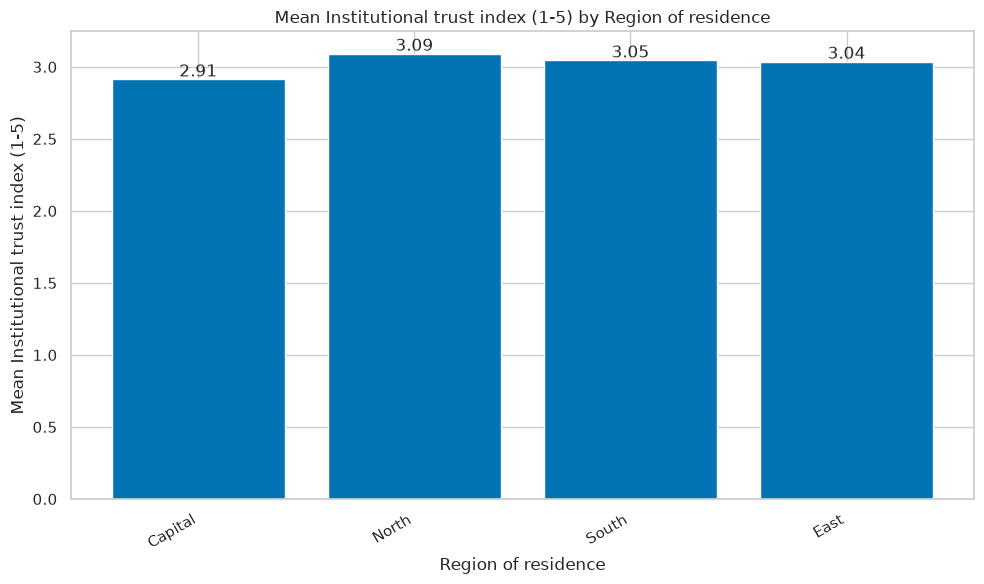

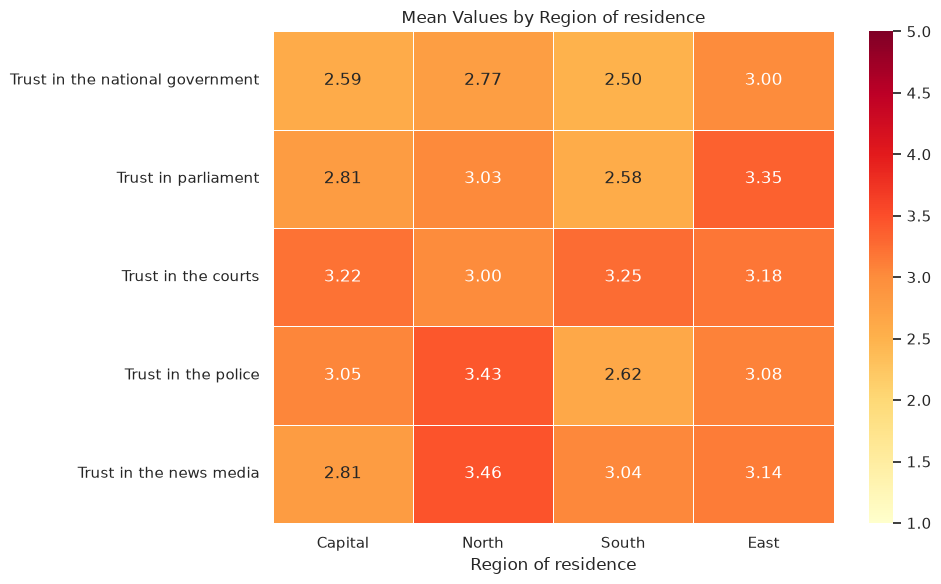

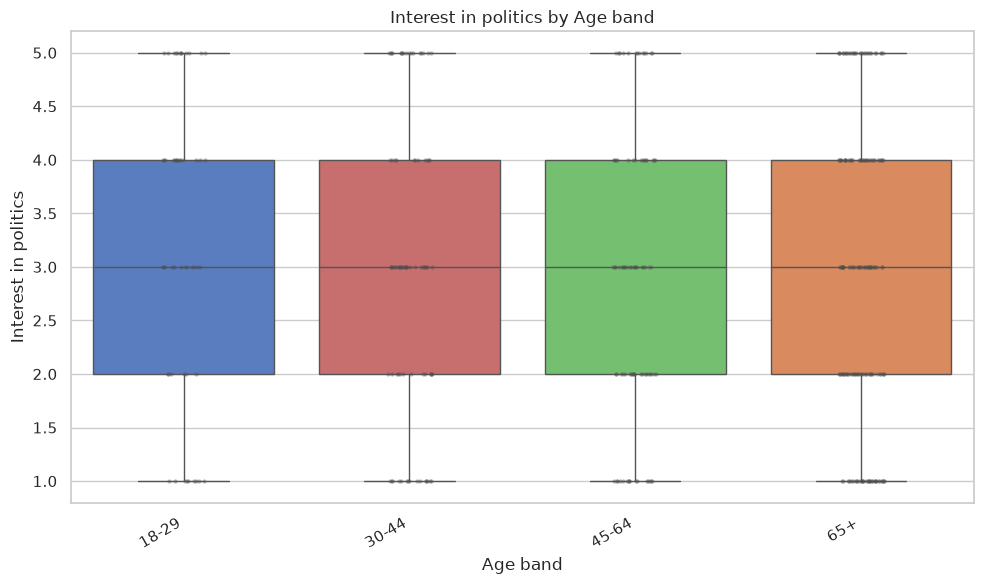

In [20]:
weighted.plot.bar("trust_index", by="region", palette="colorblind").plot(); plt.show()
weighted.plot.heatmap(trust_cols, by="region", vmin=1, vmax=5).plot(); plt.show()
weighted.plot.boxplot("interest", by="age_band", show_points=True).plot(); plt.show()

In [21]:
report = (
    sg.Report(title="Civic Trust 2026 — topline", description="Wave 1, weighted to census margins")
    .heading("Sample")
    .value("Eligible respondents", len(weighted.frame))
    .value("Effective sample size", round(weighted.analysis.effective_sample_size()))
    .add(weighted.report.freq("region"), caption="Table 1. Region (unweighted)")
    .heading("Trust in institutions")
    .add(weighted.report.means("trust_index", by="age_band"), caption="Table 2. Trust index by age band")
    .add(weighted.plot.bar("trust_index", by="region", palette="colorblind"),
         caption="Figure 1. Mean trust index by region")
    .note("Estimates in the text are weighted; tables are unweighted counts.")
)
report.save(OUT / "topline.md")       # writes fig_<block index>.png next to it
report.save(OUT / "topline.html")     # images embedded as data URIs
plt.close("all")
print(report.to_markdown(asset_dir=OUT)[:1200])

# Civic Trust 2026 — topline

*Wave 1, weighted to census margins*

## Sample

**Eligible respondents:** 388

**Effective sample size:** 301

*Table 1. Region (unweighted)*

| Value | Label | N | % | Cumulative % |
|---|---|---|---|---|
| 1 | Capital | 93 | 24.0 | 24.0 |
| 2 | North | 97 | 25.0 | 49.0 |
| 3 | South | 86 | 22.2 | 71.2 |
| 4 | East | 112 | 28.9 | 100.1 |
|  | Total | 388 | 100.0 | 100.0 |

Variable = Region of residence; N valid = 388

## Trust in institutions

*Table 2. Trust index by age band*

| Age band | Mean | SD | Median | N |
|---|---|---|---|---|
| 18-29 | 2.999 | 0.761 | 3.0 | 53 |
| 30-44 | 3.157 | 0.703 | 3.2 | 81 |
| 45-64 | 3.006 | 0.735 | 3.0 | 84 |
| 65+ | 2.976 | 0.695 | 3.0 | 170 |

F = 1.2300; p = 0.2986; N = 388; Variable = Institutional trust index (1-5)

![Figure 1. Mean trust index by region](fig_6.png)

*Figure 1. Mean trust index by region*

> **Note:** Estimates in the text are weighted; tables are unweighted counts.



In [22]:
# SPSS/Stata cannot store list-valued cells — drop the array-mode column first
flat = weighted.with_frame(weighted.frame.drop(columns=["news_sources"]))
flat.export("spss", path=str(OUT / "civic_trust.sav"))
flat.export("stata", path=str(OUT / "civic_trust.dta"))
flat.export("csv", path=str(OUT / "civic_trust.csv"))
flat.export_dictionary(str(OUT / "civic_trust_dict.json"))
flat.export("r", path=str(OUT / "civic_trust_R"))
sorted(p.name for p in OUT.iterdir())

['banner.xlsx',
 'civic_trust.csv',
 'civic_trust.dta',
 'civic_trust.sav',
 'civic_trust_R',
 'civic_trust_dict.json',
 'fig_6.png',
 'survey.db',
 'topline.html',
 'topline.md']

## 7. Stop the local server

For real fieldwork the same `survey.deploy(**options)` call takes `backend="supabase", frontend="vercel"` with credentials from `~/.siamang.toml` (`siamang init`) or `SIAMANG_*` environment variables; collect with `result.backend_ref.get_all_responses(result.survey_id)` (paginates past 1,000 rows), then `flatten_responses()` and the analysis above.

In [23]:
result.frontend_ref.stop()
print("server stopped")

server stopped
